In [1]:
from pyspark.sql import SparkSession
from delta import configure_spark_with_delta_pip

builder = SparkSession.builder \
    .appName("DeltaLakeDashboard") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.driver.memory", "4g")

spark = configure_spark_with_delta_pip(builder).getOrCreate()

In [2]:
base_path = "../delta_lake/gold/"

all_info = spark.read.format("delta").load(f"{base_path}/all_info")
avg_by_artist = spark.read.format("delta").load(f"{base_path}/avg_metrics_by_artist")
avg_by_genre = spark.read.format("delta").load(f"{base_path}/avg_metrics_by_genre")
avg_by_album_artist = spark.read.format("delta").load(f"{base_path}/avg_metrics_by_album_artist")
song_count_by_artist = spark.read.format("delta").load(f"{base_path}/song_count_by_artist")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("seaborn-v0_8-whitegrid")

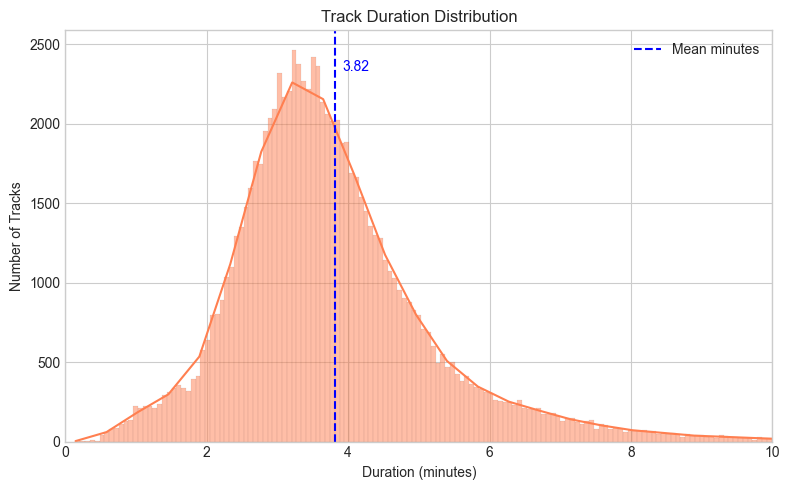

In [4]:
info_df = all_info.select("track_name", "artists", "duration_ms").toPandas()
info_df["duration_min"] = info_df["duration_ms"] / 60000

# mean 
mean_duration = info_df["duration_min"].mean()

plt.figure(figsize=(8, 5))
sns.histplot(info_df["duration_min"], bins='auto', kde=True, color="coral")

plt.axvline(mean_duration, color='blue', linestyle='--', label=f'Mean minutes')

plt.text(mean_duration + 0.1, plt.ylim()[1] * 0.9, f'{mean_duration:.2f}', color='blue')

plt.xlim(0, 10)

plt.title("Track Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Tracks")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
import plotly.graph_objects as go

# Radar chart

radar_df = avg_by_genre.select(
    "track_genre",
    "avg_danceability", 
    "avg_energy", 
    "avg_speechiness",
    "avg_acousticness", 
    "avg_instrumentalness",
    "avg_liveness",
    "avg_valence",
).toPandas()

categories = ["avg_danceability", "avg_energy", "avg_speechiness",
             "avg_acousticness", "avg_instrumentalness", "avg_liveness", "avg_valence"]
categories_clean = [c.replace("avg_", "").capitalize() for c in categories]

fig = go.Figure()

for i, row in radar_df.iterrows():
    values = [row[col] for col in categories]
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories_clean,
        fill='toself',
        name=row['track_genre'],
        visible=(i == 0)
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        showactive=True,
        x=1.15,
        y=1,
        buttons=[
            dict(
                label=radar_df.loc[i, 'track_genre'],
                method="update",
                args=[{"visible": [j == i for j in range(len(radar_df))]},
                      {"title": f"Musical Qualities by Genre – {radar_df.loc[i, 'track_genre']}"}]
            )
            for i in range(len(radar_df))
        ]
    )],
    title="Musical Qualities by Genre – " + radar_df.loc[0, 'track_genre'],
    height=600,
    width=800,
)

fig.show()

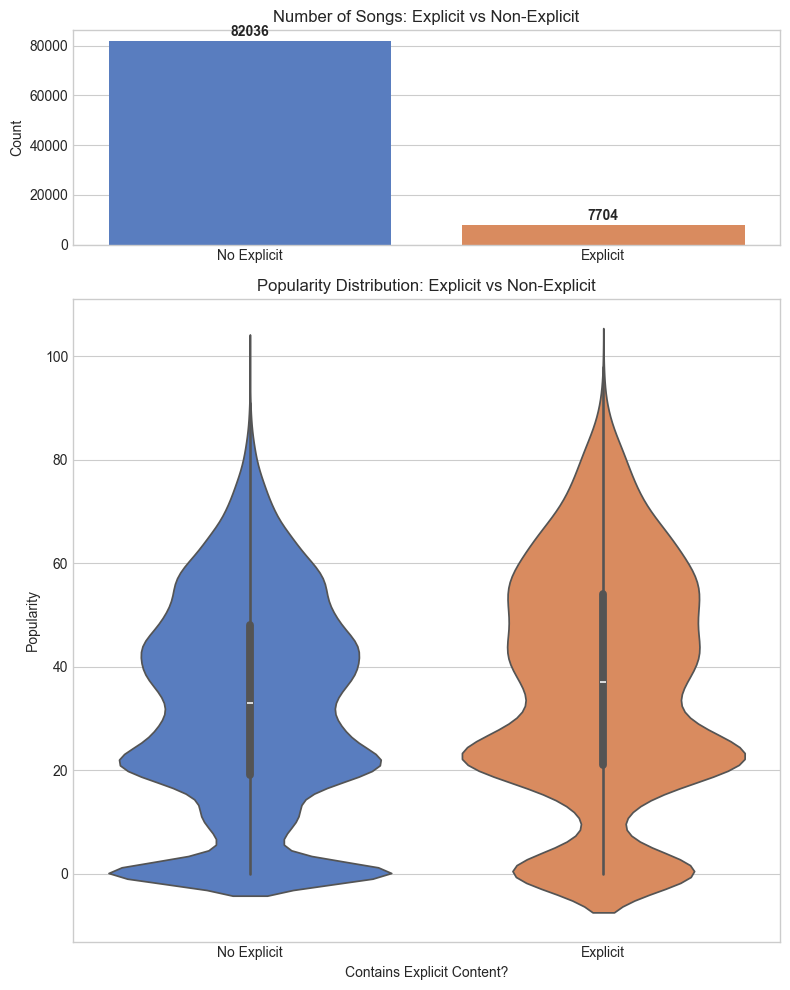

In [6]:
df = all_info.select("explicit", "popularity").toPandas()
df['explicit_label'] = df['explicit'].map({0: 'No Explicit', 1: 'Explicit'})

counts = df['explicit_label'].value_counts().reindex(['No Explicit', 'Explicit'])

fig, axes = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [1, 3]})

# Bar plot for counts
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='muted', legend=False, ax=axes[0])
axes[0].set_title('Number of Songs: Explicit vs Non-Explicit')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts.values)*0.01, str(v), ha='center', va='bottom', fontweight='bold')

# Violin plot for popularity distribution
sns.violinplot(data=df, x='explicit_label', y='popularity', hue='explicit_label', palette='muted', legend=False, ax=axes[1])
axes[1].set_title('Popularity Distribution: Explicit vs Non-Explicit')
axes[1].set_xlabel('Contains Explicit Content?')
axes[1].set_ylabel('Popularity')

plt.tight_layout()
plt.show()

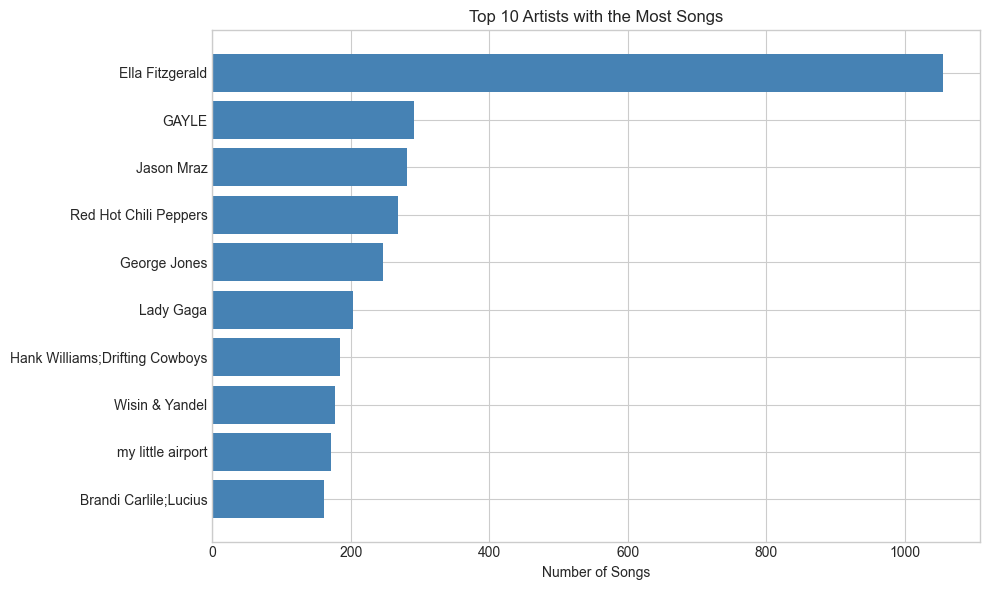

In [7]:
top_artists_df = song_count_by_artist.orderBy("song_count", ascending=False).limit(10).toPandas()

plt.figure(figsize=(10, 6))
plt.barh(top_artists_df['artists'], top_artists_df['song_count'], color='steelblue')
plt.xlabel("Number of Songs")
plt.title("Top 10 Artists with the Most Songs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()